In [7]:
pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install --upgrade pip

  Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Cell 2 — Load Cleaned Dataset

import os

# Dynamically locate the cleaned CSV relative to this notebook
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
data_path = os.path.join(base_dir, 'data', 'superstore_cleaned.csv')

df = pd.read_csv(data_path)

# Convert date columns back to datetime after loading
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print(f"Dataset loaded from : {data_path}")
print(f"Rows                : {df.shape[0]}")
print(f"Columns             : {df.shape[1]}")
print(f"\nDate range          : {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Categories          : {df['Category'].unique().tolist()}")
print(f"Regions             : {df['Region'].unique().tolist()}")

Dataset loaded from : /Users/ayushpandey/Desktop/FUTURE_ML_01/task1/data/superstore_cleaned.csv
Rows                : 9994
Columns             : 28

Date range          : 2014-01-03 to 2017-12-30
Categories          : ['Furniture', 'Office Supplies', 'Technology']
Regions             : ['South', 'West', 'Central', 'East']


In [4]:
# Cell 3 — Prepare Monthly Sales Aggregation

# Aggregate total sales per month
monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(Day=1))
monthly.sort_values('Date', inplace=True)
monthly.reset_index(drop=True, inplace=True)

# Create numeric time index for modeling
monthly['Time_Index'] = range(len(monthly))

# Lag features — previous month and 2 months ago
monthly['Lag_1'] = monthly['Sales'].shift(1)
monthly['Lag_2'] = monthly['Sales'].shift(2)

# Rolling average — 3 month window
monthly['Rolling_3'] = monthly['Sales'].shift(1).rolling(window=3).mean()

# Drop rows with nulls created by lag
monthly.dropna(inplace=True)
monthly.reset_index(drop=True, inplace=True)

print(f"Monthly records ready : {len(monthly)}")
print(f"Date range            : {monthly['Date'].min().date()} to {monthly['Date'].max().date()}")
print()
print(monthly[['Date', 'Sales', 'Lag_1', 'Lag_2', 'Rolling_3']].head())


Monthly records ready : 45
Date range            : 2014-04-01 to 2017-12-01

        Date       Sales       Lag_1       Lag_2     Rolling_3
0 2014-04-01  28295.3450  55691.0090   4519.8920  24815.932000
1 2014-05-01  23648.2870  28295.3450  55691.0090  29502.082000
2 2014-06-01  34595.1276  23648.2870  28295.3450  35878.213667
3 2014-07-01  33946.3930  34595.1276  23648.2870  28846.253200
4 2014-08-01  27909.4685  33946.3930  34595.1276  30729.935867


In [5]:
# Cell 4 — Train Test Split and Model Training

features = ['Time_Index', 'Month', 'Lag_1', 'Lag_2', 'Rolling_3']
target   = 'Sales'

X = monthly[features]
y = monthly[target]

# Last 6 months as test set, rest as training
split_index = len(monthly) - 6
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("\nModels trained successfully")

Training samples : 39
Test samples     : 6

Models trained successfully


In [6]:
# Cell 5 — Evaluate Both Models

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MAE  : ${mae:,.0f}")
    print(f"  RMSE : ${rmse:,.0f}")
    print(f"  R2   : {r2:.4f}")
    print()

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest",     y_test, rf_preds)

# Pick the best model based on RMSE
lr_rmse = mean_squared_error(y_test, lr_preds) ** 0.5
rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5

best_model  = rf if rf_rmse < lr_rmse else lr
best_preds  = rf_preds if rf_rmse < lr_rmse else lr_preds
best_name   = "Random Forest" if rf_rmse < lr_rmse else "Linear Regression"

print(f"Best model selected : {best_name}")

Linear Regression
  MAE  : $12,821
  RMSE : $17,841
  R2   : 0.3736

Random Forest
  MAE  : $16,724
  RMSE : $20,621
  R2   : 0.1632

Best model selected : Linear Regression


In [8]:
# Cell 6 — Forecast Next 3 Months

last_row      = monthly.iloc[-1]
last_index    = last_row['Time_Index']
last_date     = last_row['Date']
last_sales    = last_row['Sales']
last_lag1     = last_row['Sales']
last_lag2     = monthly.iloc[-2]['Sales']
last_rolling3 = monthly['Sales'].iloc[-3:].mean()

forecast_records = []
temp_lag1    = last_lag1
temp_lag2    = last_lag2
temp_rolling = last_rolling3

for i in range(1, 4):
    next_date    = last_date + pd.DateOffset(months=i)
    next_month   = next_date.month
    next_index   = last_index + i

    X_future = pd.DataFrame([{
        'Time_Index' : next_index,
        'Month'      : next_month,
        'Lag_1'      : temp_lag1,
        'Lag_2'      : temp_lag2,
        'Rolling_3'  : temp_rolling
    }])

    pred = best_model.predict(X_future)[0]

    forecast_records.append({
        'Date'          : next_date,
        'Forecasted_Sales' : round(pred, 2)
    })

    # Update lags for next iteration
    temp_lag2    = temp_lag1
    temp_lag1    = pred
    temp_rolling = (temp_rolling * 2 + pred) / 3

forecast_df = pd.DataFrame(forecast_records)
print("3-Month Sales Forecast")
print(forecast_df.to_string(index=False))

3-Month Sales Forecast
      Date  Forecasted_Sales
2018-01-01          38100.74
2018-02-01          47484.56
2018-03-01          51493.61


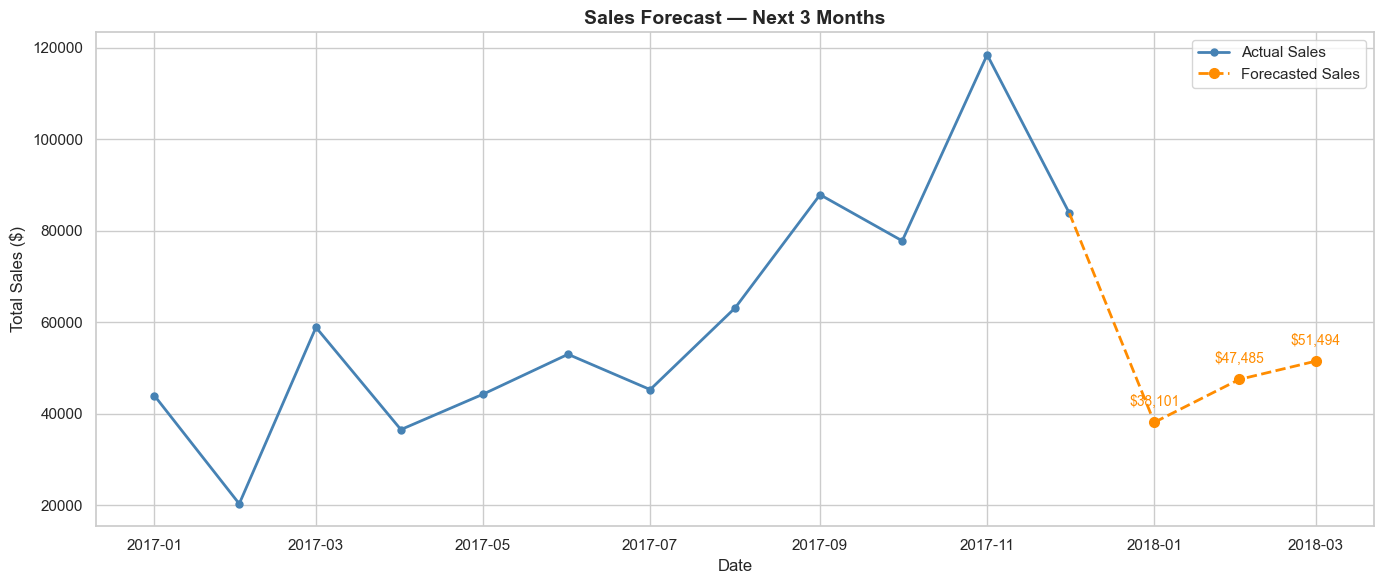

Chart saved to : /Users/ayushpandey/Desktop/FUTURE_ML_01/task1/outputs/charts/sales_forecast.png


In [9]:
# Cell 7 — Forecast Visualization

import os

output_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'charts'))
os.makedirs(output_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot last 12 months actual
actual_tail = monthly.tail(12)
ax.plot(actual_tail['Date'], actual_tail['Sales'],
        color='steelblue', linewidth=2, marker='o',
        markersize=5, label='Actual Sales')

# Plot forecast
ax.plot(forecast_df['Date'], forecast_df['Forecasted_Sales'],
        color='darkorange', linewidth=2, marker='o',
        markersize=7, linestyle='--', label='Forecasted Sales')

# Connect last actual to first forecast
ax.plot([actual_tail['Date'].iloc[-1], forecast_df['Date'].iloc[0]],
        [actual_tail['Sales'].iloc[-1], forecast_df['Forecasted_Sales'].iloc[0]],
        color='darkorange', linewidth=2, linestyle='--')

# Annotate forecast values
for _, row in forecast_df.iterrows():
    ax.annotate(f"${row['Forecasted_Sales']:,.0f}",
                xy=(row['Date'], row['Forecasted_Sales']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10, color='darkorange')

ax.set_title('Sales Forecast — Next 3 Months', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales ($)')
ax.legend()
plt.tight_layout()

chart_path = os.path.join(output_dir, 'sales_forecast.png')
plt.savefig(chart_path, dpi=150)
plt.show()
print(f"Chart saved to : {chart_path}")

In [10]:
# Cell 8 — Save Forecast CSV

output_dir   = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs'))
forecast_path = os.path.join(output_dir, 'forecast.csv')

forecast_df.to_csv(forecast_path, index=False)
print(f"Forecast saved to : {forecast_path}")
print()
print(forecast_df.to_string(index=False))

Forecast saved to : /Users/ayushpandey/Desktop/FUTURE_ML_01/task1/outputs/forecast.csv

      Date  Forecasted_Sales
2018-01-01          38100.74
2018-02-01          47484.56
2018-03-01          51493.61
